# Customer Segmentation System

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rajeevgautam335","key":"98d2da5dc5e5dce52c99688a5b0356d1"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d vetrirah/customer

Dataset URL: https://www.kaggle.com/datasets/vetrirah/customer
License(s): CC0-1.0
  0% 0.00/105k [00:00<?, ?B/s]
100% 105k/105k [00:00<00:00, 263MB/s]


In [ ]:
!unzip customer.zip

Archive:  customer.zip
  inflating: Test.csv                
  inflating: Train.csv               
  inflating: sample_submission.csv   


In [ ]:
df = pd.read_csv("Train.csv")
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [ ]:
def encode_gender(df, col='Gender'):

    df[col] = df[col].map({'Male': 1, 'Female': 0})
    return df
df = encode_gender(df)

In [ ]:
def encode_yes_no(df, col):

    df[col] = df[col].map({'Yes': 1, 'No': 0})
    return df

In [ ]:
df = encode_yes_no(df, 'Ever_Married')
df = encode_yes_no(df, 'Graduated')

In [ ]:
def encode_spending_score(df, col='Spending_Score'):
    mapping = {
        'Low': 0,
        'Average': 1,
        'High': 2
    }
    df[col] = df[col].map(mapping)
    return df

In [ ]:
df = encode_spending_score(df)

In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [ ]:
df["Ever_Married"]=df["Ever_Married"].fillna(value=df["Ever_Married"].median)
df["Work_Experience"]=df["Work_Experience"].fillna(value=df["Work_Experience"].median)
df["Family_Size"]=df["Family_Size"].fillna(value=df["Family_Size"].median)
df["Profession"]=df["Profession"].fillna(value=df["Profession"].median)
df["Graduated"]=df["Graduated"].fillna(value=df["Graduated"].median)

In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,76


In [ ]:
df = df.drop(columns=['ID', 'Segmentation', 'Var_1'])

In [ ]:
df.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size
0,1,0.0,22,0.0,Healthcare,1.0,0,4.0
1,0,1.0,38,1.0,Engineer,<bound method Series.median of 0 1.0\n1 ...,1,3.0
2,0,1.0,67,1.0,Engineer,1.0,0,1.0
3,1,1.0,67,1.0,Lawyer,0.0,2,2.0
4,0,1.0,40,1.0,Entertainment,<bound method Series.median of 0 1.0\n1 ...,2,6.0


In [ ]:
df["Profession"].unique()

array(['Healthcare', 'Engineer', 'Lawyer', 'Entertainment', 'Artist',
       'Executive', 'Doctor', 'Homemaker', 'Marketing',
       <bound method Series.median of 0          Healthcare
       1            Engineer
       2            Engineer
       3              Lawyer
       4       Entertainment
                   ...
       8063              NaN
       8064        Executive
       8065       Healthcare
       8066       Healthcare
       8067        Executive
       Name: Profession, Length: 8068, dtype: object>      ], dtype=object)

In [ ]:
df['Profession'] = df['Profession'].fillna(df['Profession'].mode()[0])

df = pd.get_dummies(
    df,
    columns=['Profession'],
    drop_first=True
)

In [ ]:
df.head()

,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,1,0.0,22,0.0,1.0,0,4.0,False,False,False,False,False,True,False,False,False
1,0,1.0,38,1.0,<bound method Series.median of 0 1.0\n1 ...,1,3.0,False,False,True,False,False,False,False,False,False
2,0,1.0,67,1.0,1.0,0,1.0,False,False,True,False,False,False,False,False,False
3,1,1.0,67,1.0,0.0,2,2.0,False,False,False,False,False,False,False,True,False
4,0,1.0,40,1.0,<bound method Series.median of 0 1.0\n1 ...,2,6.0,False,False,False,True,False,False,False,False,False


In [ ]:
X = df.select_dtypes(include=['int64', 'float64', 'uint8'])

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

In [ ]:
wcss = []

In [ ]:
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

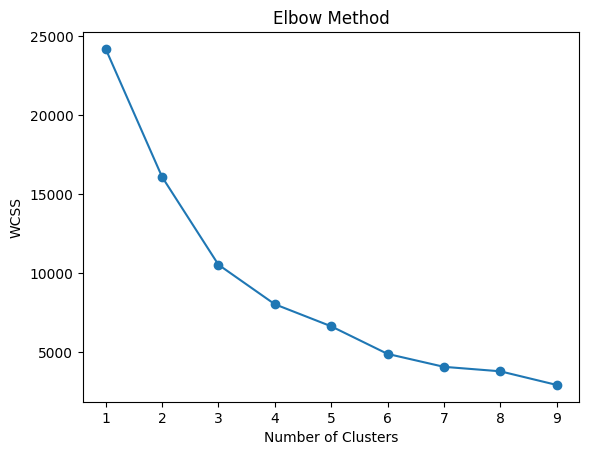

In [ ]:
plt.plot(range(1, 10), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

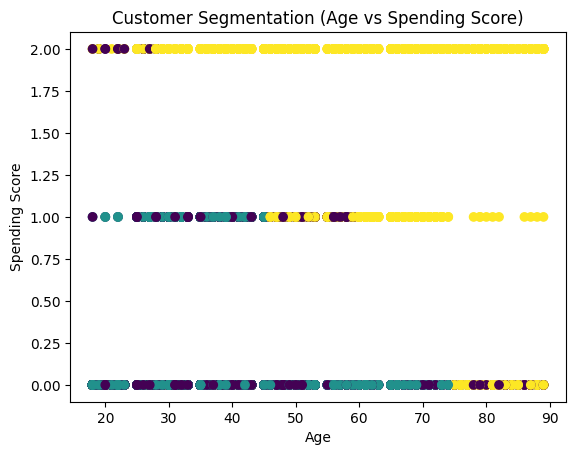

In [ ]:
plt.scatter(
    df['Age'],
    df['Spending_Score'],
    c=df['Cluster'],
)

plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation (Age vs Spending Score)")
plt.show()